# Лабораторна 2. Від сирих даних до нейромережі

У цій лабораторній роботі ви пройдете повний цикл роботи з табличним датасетом для задачі регресії — від завантаження до порівняння моделей:

- дослідницький аналіз даних (EDA): загальний огляд, гістограми, кореляції;
- обробка пропусків і викидів;
- інженерія ознак;
- baseline: множинна лінійна регресія;
- нейромережа — підбір архітектури, функцій активації, оптимізатора власними експериментами;
- чесне порівняння моделей на test за метриками регресії (MSE, RMSE, MAE, R²).

Демо-ноутбук з лекції 3-4 — основа, звертайтесь до нього як до довідника, коли щось незрозуміло.

## 0. Опрацюйте демо-ноутбук з лекції
Прогляньте пояснення ноутбуку і запустіть всі клітинки демо-ноутбуку (крім тих секцій, в яких вказано, що їх запускати не можна).
Після цього дайте тут відповідь на запитання:
1. Чому для заповнення пропусків було обрано метод kNN?
2. Чому при тренуванні лінійної регресії train і val порівнюються лише на основі MSE, а після тренування на основі багатьох функцій? Проекспериментуйте в межах тренування з вибором функції і поділіться результатами.
3. Які висновки після клітинки 2.6 в демо Ви можете зробити?
4. Поясни для чого потрібен baseline в лінійній регресії і як він вираховується? Що є baseline для нейронної мережі?
5. Продемонструй дію всіх функцій активації на графіку функцій, згенерувавши 1000 випадкових значень Х і порахувавши для них Y через ці функції.
6. Яким чином в нейронній мережі утворилася така кількість параметрів, яка вказана після виконання 3.3?
7. Чи оптимально вибрано кількість епох в 3.5?

### 0.1 Мої відповіді:
1. kNN враховує залежності між усіма ознаками та заповнює пропуски на основі схожих сусідів, тоді як прості медіана чи мода працюють із кожною колонкою ізольовано.
2. MSE під час тренування та розширені метрики після: MSE - це гладка й диференційовна функція, необхідна для стабільного обчислення градієнтів оптимізатором. Комплекс метрик після тренування дає всебічну оцінку якості в різних вимірах. Навчання з MAE  спричиняє осциляцію ваг через постійний за модулем градієнт, а MSE забезпечує плавну збіжність.
3. Після стандартизації абсолютне значення ваги показує її важливість. MedInc є найсильнішим чинником, а створені ознаки diag_coord та bedperroom отримали значні ваги, що доводить ефективність feature engineering.
4. Для лінійної регресії - це константний прогноз середнього значення. Для нейромережі baseline - це навчена модель лінійної регресії.
5.
6.
1) Linear(7, 64): 7*64+64=512
2) Linear(64, 32): 64*32+32=2080
3) Linear(32, 1): 32*1+1=33
4) Загалом: 512+2080+33=2625
7. Ні. Помилки train і val спадають без перенавчання, але крива ще не вийшла на плато - краще збільшити кількість епох до 300–400 і додати Early Stopping.


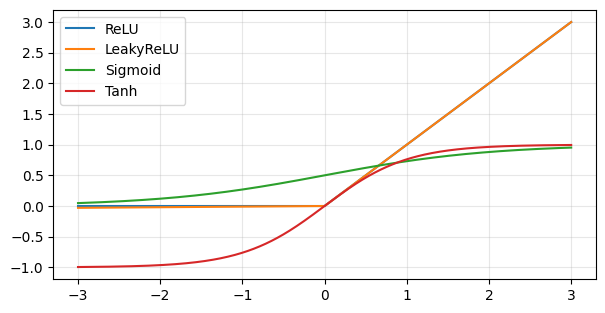

In [1]:
# 5. Продемонструй дію всіх функцій активації на графіку функцій, згенерувавши 1000 випадкових значень Х і порахувавши для них Y через ці функції.
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(-3, 3, 1000)
plt.figure(figsize=(7, 3.5))
plt.plot(x, np.maximum(0, x), label="ReLU")
plt.plot(x, np.where(x > 0, x, 0.01 * x), label="LeakyReLU")
plt.plot(x, 1 / (1 + np.exp(-x)), label="Sigmoid")
plt.plot(x, np.tanh(x), label="Tanh")
plt.grid(True, alpha=0.3); plt.legend(); plt.show()

---
## 1. Датасети

Ви отримаєте один з 10 датасетів нижче. Усі — задачі регресії на Hugging Face: табличні дані, здебільшого числові ознаки, від кількасот до кількадесяти тисяч рядків.

1. **[King County House Sales](https://huggingface.co/datasets/kraina/house_sales_in_king_county)** — 21 613 продажів будинків (Вашингтон, 2014–2015). Таргет: `price`. ⚠️ `load_dataset("kraina/house_sales_in_king_county")` не працює (застарілий loading-скрипт) — вантажте напряму: `load_dataset("parquet", data_files="https://huggingface.co/datasets/kraina/house_sales_in_king_county/resolve/main/data/house_sales_king_county.parquet")`.
2. **[Diamonds](https://huggingface.co/datasets/jdxcosta/diamonds)** — 53 940 діамантів. Таргет: `price`. Ознаки: вага (`carat`), огранка, колір, чистота, розміри.
3. **[Concrete Compressive Strength](https://huggingface.co/datasets/foundry-ml/dataset_concrete_compressive_strength)** — 1 030 замісів бетону. Таргет: міцність на стиск. Усі ознаки числові (склад суміші + вік).
4. **[Auto MPG](https://huggingface.co/datasets/scikit-learn/auto-mpg)** — 398 автомобілів. Таргет: `mpg` (витрата пального). Найменший і найпростіший датасет зі списку.
5. **[Wine Quality](https://huggingface.co/datasets/codesignal/wine-quality)** — 1 599 (червоне) + 4 898 (біле) вин. Таргет: `quality` (оцінка 3–9). Усі ознаки — хімічний склад, числові.
6. **[Laptop Price](https://huggingface.co/datasets/Ammok/laptop_price_prediction)** — 977 + 325 ноутбуків. Таргет: `Price`. Частина ознак текстові (`RAM`, `Storage`, `CPU`) — доведеться парсити в числа.
7. **[Bike Sharing Demand](https://huggingface.co/datasets/t22000t/bike-sharing-tabular)** — 17 379 годинних записів прокату велосипедів. Таргет: `cnt`. Часові й погодні ознаки.
8. **[Ames House Prices](https://huggingface.co/datasets/t22000t/house-prices-tabular)** — 1 460 будинків, 79 ознак. Таргет: `SalePrice`. Найбільше категоріальних ознак зі списку — гарна практика на encoding.
9. **[Medical Insurance Cost](https://huggingface.co/datasets/harishsohani/medical-insurance-cost-prediction)** — 1 338 застрахованих. Таргет: `charges`. Компактний, мало ознак — хороший старт, якщо часу мало. ⚠️ У репозиторії кілька CSV одразу (`Xtrain`/`Xtest`/`insurance.csv`) — вкажіть файл явно: `load_dataset("harishsohani/medical-insurance-cost-prediction", data_files="insurance.csv")`.
10. **[Abalone](https://huggingface.co/datasets/mstz/abalone)** — 4 177 молюсків. Таргет: `number_of_rings` (вік). Усі ознаки — фізичні виміри, окрім `sex`.

Решта (2–5, 7–8, 10) вантажаться напряму — `load_dataset("<repo_id>")` без додаткових аргументів, HF-токен не потрібен.

### 1.1. Який датасет мій?

Визначте самі власний датасет: беремо Ваше ПІБ, рахуємо SHA-256 хеш, залишок від ділення на 10 — це індекс у списку датасетів вище (0 → перший, 9 → останній).

**Формат ПІБ:** точно як у списку групи — `Прізвище Ім'я По-батькові`, по одному пробілу між словами, без зайвих пробілів на початку/в кінці. Якщо використаєте інший формат - **не зарахую лабу**!!!

In [12]:
import hashlib

DATASETS = [
    "King County House Sales",
    "Diamonds",
    "Concrete Compressive Strength",
    "Auto MPG",
    "Wine Quality",
    "Laptop Price",
    "Bike Sharing Demand",
    "Ames House Prices",
    "Medical Insurance Cost",
    "Abalone",
]

FULL_NAME = "Айсін Владислав Сергійович" # TODO: впишіть своє ПІБ точно як у списку групи

dataset_index = int(hashlib.sha256(FULL_NAME.encode("utf-8")).hexdigest(), 16) % len(DATASETS)
print(f"Ваш датасет (#{dataset_index + 1}):", DATASETS[dataset_index])

Ваш датасет (#9): Medical Insurance Cost


---
## 2. Що потрібно зробити

Нижче — загальний план роботи, без коду: код і пояснення до кожного кроку дивіться в **демо-ноутбуці лекції 3-4**, номери розділів позначені в дужках. Ваша задача — повторити той самий підхід на своєму датасеті, а не скопіювати код один в один: у вашого датасету інші колонки, інші типи пропусків (чи їх взагалі нема), інші викиди (чи їх нема) — рішення на кожному кроці обґрунтовуйте під свої дані, а не тому, що "так було в демо".

### 2.1. Підготовка даних

1. Завантажте свій датасет (демо 1.1) і перетворіть на `pandas.DataFrame` (1.2).
2. Зробіть спліт **train / val / test** одразу, до будь-якого аналізу (1.3) — і поясніть своїми словами, чому саме в такому порядку (нагадування: data leakage).
3. Загальний огляд (`head`/`info`/`describe`, 1.4).
4. Обробка пропусків (1.5) — **якщо вони є**. Немає пропусків — так і напишіть, це теж валідний результат, не треба їх штучно вигадувати.
5. EDA (1.6): хоча б гістограми і кореляційна матриця. Що впадає в очі у ваших даних — capping, скошені розподіли, мультиколінеарність?
6. Обробка викидів (1.7) — **за потреби**, з обґрунтуванням: звідки взявся викид і чому саме таке рішення (видалити / трансформувати / залишити).
7. Інженерія ознак (1.8) — **за потреби**: чи є сенс комбінувати/прибирати ознаки з високою кореляцією між собою.

### 2.2. Baseline: множинна лінійна регресія

Стандартизація ознак (2.1), тензори (2.2), тренування `nn.Linear` (2.3), крива навчання (2.4), метрики на test — MSE/RMSE/MAE/R² (2.5), інтерпретація ваг (2.6).

Це ваш **варіант #1**, точка відліку для всього, що далі.

### 2.3. Нейромережа: щонайменше 2 різні архітектури

За зразком розділу 3 демо: `nn.Sequential` з прихованими шарами, ReLU, оптимізатор Adam.

Спробуйте **мінімум 2 архітектури**, які відрізняються не косметично — напр. різна кількість шарів, різна ширина шарів, чи інша функція активації (3.2). Кожна — окремий варіант.

### 2.4. Підбір гіперпараметрів: щонайменше 3 зміни

Візьміть архітектуру, яка показала себе краще, і поекспериментуйте з гіперпараметрами: learning rate, оптимізатор (SGD/Adam), кількість епох, розмір batch (якщо вирішите його ввести) тощо. Змінюйте **по одному параметру за раз** — інакше не зрозумієте, що саме вплинуло на результат.

**Разом (2.2 + 2.3 + 2.4):** щонайменше 5 варіантів моделі (1 лінійна + 2 архітектури + 2 гіперпараметри), до **10 варіантів** — якщо є час і бажання поекспериментувати більше, це тільки заохочується.

### 2.5. Логування і порівняння

Кожен варіант (2.2-2.4) логуйте в TensorBoard в окрему підпапку `RUNS_DIR` (як у 2.3/3.5 демо) — з осмисленою назвою (`linear`, `nn_v1_2layers`, `nn_v2_deeper`, `nn_v2_lr_0.001`, ...), щоб потім усі криві можна було накласти одна на одну (3.8 демо) і візуально порівняти.

Наприкінці зведіть усі варіанти в одну таблицю (модель → MSE/RMSE/MAE/R² на test) і дайте коротку письмову відповідь:
- Яка модель перемогла і наскільки суттєво?
- Чи виправдала себе нейромережа порівняно з лінійною регресією на вашому датасеті?
- Що з ваших змін (архітектура чи гіперпараметри) дало найбільший ефект?

In [3]:
#2.1 (1)
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42
def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODELS_DIR = "lab2/models"
RUNS_DIR = "lab2/runs"
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RUNS_DIR, exist_ok=True)
raw_dataset = load_dataset("harishsohani/medical-insurance-cost-prediction", data_files="insurance.csv")
insurance_df = raw_dataset["train"].to_pandas()
print("Загальний розмір таблиці:", insurance_df.shape)

Загальний розмір таблиці: (1338, 7)


In [4]:
# 2.1 (2)
insurance_df = pd.get_dummies(insurance_df, columns=["sex", "smoker", "region"], drop_first=True, dtype=float)
train_df, temp_df = train_test_split(insurance_df, test_size=0.4, random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED)
print(f"Розмір навчальної вибірки (train): {train_df.shape}")
print(f"Розмір валідаційної вибірки (val): {val_df.shape}")
print(f"Розмір тестової вибірки (test): {test_df.shape}")

Розмір навчальної вибірки (train): (802, 9)
Розмір валідаційної вибірки (val): (268, 9)
Розмір тестової вибірки (test): (268, 9)


In [5]:
# 2.1 (3)
train_df.head()
train_df.info()
train_df.describe()
print("Залишилось пропусків (train):", train_df.isna().sum().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 802 entries, 25 to 1126
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               802 non-null    int64  
 1   bmi               802 non-null    float64
 2   children          802 non-null    int64  
 3   charges           802 non-null    float64
 4   sex_male          802 non-null    float64
 5   smoker_yes        802 non-null    float64
 6   region_northwest  802 non-null    float64
 7   region_southeast  802 non-null    float64
 8   region_southwest  802 non-null    float64
dtypes: float64(7), int64(2)
memory usage: 62.7 KB
Залишилось пропусків (train): 0


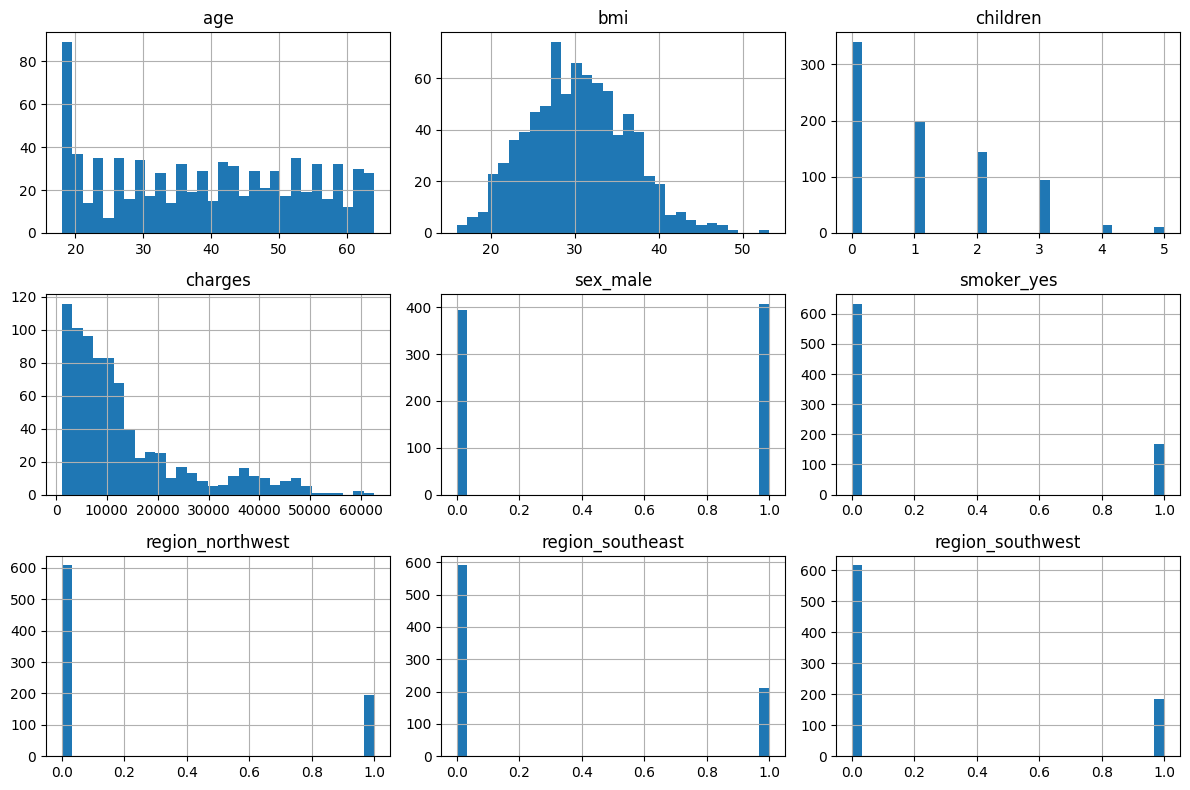

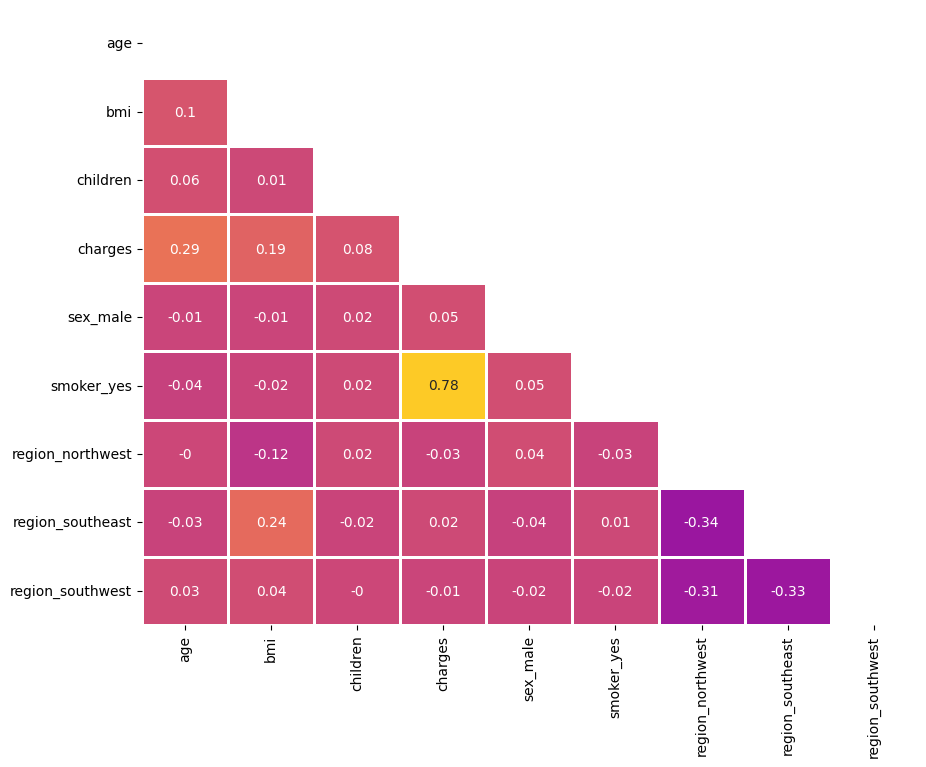

In [6]:
# 2.1 (4)
train_df.hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()
def corr_mat(df):
    corr = df.corr().round(2)
    f, ax = plt.subplots(figsize=(10, 8))
    mask = np.zeros_like(corr, dtype=bool)
    mask[np.triu_indices_from(mask)] = True
    sns.heatmap(corr, mask=mask, vmin=-1, vmax=1, center=0,
                cmap="plasma", square=False, lw=2, annot=True, cbar=False)
    plt.show()
corr_mat(train_df)

In [7]:
# 2.1 (5)
target_col = "charges"
feature_cols = [c for c in train_df.columns if c != target_col]
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[feature_cols])
X_val = scaler.transform(val_df[feature_cols])
X_test = scaler.transform(test_df[feature_cols])
y_train = train_df[target_col].values
y_val = val_df[target_col].values
y_test = test_df[target_col].values
def to_tensor(X, y):
    return (
        torch.tensor(X, dtype=torch.float32).to(device),
        torch.tensor(y, dtype=torch.float32).unsqueeze(1).to(device),
    )
x_train_t, y_train_t = to_tensor(X_train, y_train)
x_val_t, y_val_t = to_tensor(X_val, y_val)
x_test_t, y_test_t = to_tensor(X_test, y_test)

In [8]:
# 2.2
N_EPOCHS = 300
n_features = X_train.shape[1]
linear_model = nn.Linear(in_features=n_features, out_features=1).to(device)
with torch.no_grad():
    linear_model.bias.fill_(float(y_train.mean()))
optimizer = torch.optim.Adam(linear_model.parameters(), lr=50.0)
loss_fn = nn.MSELoss()
writer = SummaryWriter(log_dir=os.path.join(RUNS_DIR, "linear"))
for epoch in range(N_EPOCHS):
    linear_model.train()
    optimizer.zero_grad()
    y_pred = linear_model(x_train_t)
    loss = loss_fn(y_pred, y_train_t)
    loss.backward()
    optimizer.step()
    linear_model.eval()
    with torch.no_grad():
        val_loss = loss_fn(linear_model(x_val_t), y_val_t).item()
    writer.add_scalar("Loss/train", loss.item(), epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)
writer.close()
torch.save(linear_model.state_dict(), os.path.join(MODELS_DIR, "linear.pt"))
def report_metrics(model, x_t, y_true):
    model.eval()
    with torch.no_grad():
        preds = model(x_t).cpu().numpy().flatten()
    mse = mean_squared_error(y_true, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, preds)
    r2 = r2_score(y_true, preds)
    return mse, rmse, mae, r2
lin_mse, lin_rmse, lin_mae, lin_r2 = report_metrics(linear_model, x_test_t, y_test)
print(f"Linear Regression: MSE={lin_mse:.2f} RMSE={lin_rmse:.2f} MAE={lin_mae:.2f} R2={lin_r2:.4f}")

Linear Regression: MSE=38361722.48 RMSE=6193.68 MAE=4631.55 R2=0.7527


In [9]:
# 2.3-2.4
results = [
    {"Model": "linear", "MSE": lin_mse, "RMSE": lin_rmse, "MAE": lin_mae, "R2": lin_r2}
]
def train_and_eval(model, run_name, lr=10.0, epochs=300, optimizer_cls=torch.optim.Adam):
    model = model.to(device)
    with torch.no_grad():
        list(model.children())[-1].bias.fill_(float(y_train.mean()))
    optimizer = optimizer_cls(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    writer = SummaryWriter(log_dir=os.path.join(RUNS_DIR, run_name))
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        y_pred = model(x_train_t)
        loss = loss_fn(y_pred, y_train_t)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=100.0)
        optimizer.step()
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(x_val_t), y_val_t).item()
        writer.add_scalar("Loss/train", loss.item(), epoch)
        writer.add_scalar("Loss/val", val_loss, epoch)
    writer.close()
    torch.save(model.state_dict(), os.path.join(MODELS_DIR, f"{run_name}.pt"))
    mse, rmse, mae, r2 = report_metrics(model, x_test_t, y_test)
    return {"Model": run_name, "MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2}, model

nn_v1 = nn.Sequential(
    nn.Linear(n_features, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)
res_v1, model_v1 = train_and_eval(nn_v1, "nn_v1", lr=10.0, epochs=300)
results.append(res_v1)

nn_v2 = nn.Sequential(
    nn.Linear(n_features, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)
res_v2, model_v2 = train_and_eval(nn_v2, "nn_v2", lr=10.0, epochs=300)
results.append(res_v2)

nn_v3 = nn.Sequential(
    nn.Linear(n_features, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)
res_v3, model_v3 = train_and_eval(nn_v3, "nn_v2_lr_20", lr=20.0, epochs=300)
results.append(res_v3)

nn_v4 = nn.Sequential(
    nn.Linear(n_features, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)
res_v4, model_v4 = train_and_eval(nn_v4, "nn_v2_sgd", lr=1e-5, epochs=300, optimizer_cls=torch.optim.SGD)
results.append(res_v4)

In [10]:
# 2.5
results_df = pd.DataFrame(results)
results_df.to_csv("lab2/results.csv", index=False)
print(results_df.to_string(index=False))

      Model          MSE         RMSE         MAE        R2
     linear 3.836172e+07  6193.684079 4631.553912  0.752681
      nn_v1 1.561336e+08 12495.342114 9475.244628 -0.006599
      nn_v2 1.561336e+08 12495.341560 9475.246770 -0.006598
nn_v2_lr_20 1.561336e+08 12495.341560 9475.246770 -0.006598
  nn_v2_sgd 1.561315e+08 12495.258804 9475.199054 -0.006585


---
## 3. Gradio-застосунок: порівняння всіх варіантів наживо

Побудуйте аппку для своїх моделей

In [11]:
# 3
import gradio as gr

models = {
    "linear": linear_model,
    "nn_v1": model_v1,
    "nn_v2": model_v2,
    "nn_v2_lr_20": model_v3,
    "nn_v2_sgd": model_v4,
}

def predict_all(*feature_values):
    x = scaler.transform(pd.DataFrame([feature_values], columns=feature_cols))
    x_t = torch.tensor(x, dtype=torch.float32).to(device)
    preds = {}
    for name, model in models.items():
        model.eval()
        with torch.no_grad():
            preds[name] = model(x_t).item()
    return preds

def predict_selected(selected_model, *feature_values):
    return predict_all(*feature_values)[selected_model]

def plot_comparison(*feature_values):
    preds = predict_all(*feature_values)
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(preds.keys(), list(preds.values()))
    ax.set_ylabel("Прогноз charges ($)")
    ax.set_title("Порівняння моделей")
    plt.xticks(rotation=15)
    plt.tight_layout()
    return fig

def run_prediction(selected_model, *feature_values):
    return predict_selected(selected_model, *feature_values), plot_comparison(*feature_values)

with gr.Blocks(title="Medical Insurance Cost - Порівняння моделей") as demo:
    gr.Markdown("## Прогноз страхових витрат (charges) — порівняння моделей")
    with gr.Row():
        with gr.Column():
            sliders = [
                gr.Slider(
                    minimum=float(train_df[col].min()),
                    maximum=float(train_df[col].max()),
                    value=float(train_df[col].mean()),
                    label=col,
                )
                for col in feature_cols
            ]
            model_choice = gr.Dropdown(
                choices=list(models.keys()),
                value="nn_v2",
                label="Основна модель",
            )
            submit_btn = gr.Button("Порахувати прогноз", variant="primary")
        with gr.Column():
            prediction_output = gr.Number(label="Прогноз обраної моделі ($)")
            comparison_plot = gr.Plot(label="Порівняння всіх варіантів")

    submit_btn.click(
        fn=run_prediction,
        inputs=[model_choice] + sliders,
        outputs=[prediction_output, comparison_plot],
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1b72dfbd863575d640.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
### Як здавати лабу

У форму (https://forms.gle/8Dbc9zB8L5tsNuNEA) здати посилання на **публічний** репозиторій, який містить:

1. **Цей ноутбук з усіма виконаними пунктами**. Має запускатися зверху до низу (Run All) в будь-якому середовищі без помилок.
2. **Файли всіх натренованих варіантів моделі** (2.2-2.4) — лінійна регресія + всі варіанти нейромережі, кожен окремим `.pt` файлом.
3. **Логи TensorBoard** — папка `runs/` з усіма прогонами, щоб можна було відкрити криві навчання, не перезапускаючи ноутбук.
4. **Таблицю результатів** — `results.csv` з порівнянням усіх варіантів (модель, MSE, RMSE, MAE, R² на test).
5. Структура файлів на репозиторії, **точно дотримуйтесь, інакше не зарахується лаба**:
```
/lab2/nn_task.ipynb
/lab2/models/linear.pt
/lab2/models/nn_v1.pt
/lab2/models/nn_v2.pt
/lab2/models/...        (усі інші варіанти з 2.3-2.4)
/lab2/runs/*
/lab2/results.csv
```